In [21]:
%store -r df
from prophet import Prophet
import matplotlib.pyplot as plt
#metrics
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import mean_squared_error





In [ ]:
# CHECK DATA
print(df.head())

# CHECK COLUMN TYPES
#print(df.dtypes)
# date datatype from string to dfatetime64[us] prophet deosnt use str dates
print(df.columns)
df['Date'] = pd.to_datetime(df['Date'])
print(df.dtypes)

Index(['Date', 'Store ID', 'Product ID', 'Category', 'Region',
       'Inventory Level', 'Units Sold', 'Units Ordered', 'Demand Forecast',
       'Price', 'Discount', 'Weather Condition', 'Holiday/Promotion',
       'Competitor Pricing', 'Seasonality'],
      dtype='str')
Date                  datetime64[us]
Store ID                         str
Product ID                       str
Category                         str
Region                           str
Inventory Level                int64
Units Sold                     int64
Units Ordered                  int64
Demand Forecast              float64
Price                        float64
Discount                       int64
Weather Condition                str
Holiday/Promotion              int64
Competitor Pricing           float64
Seasonality                      str
dtype: object


In [10]:
#grouping all the  similar dates and adding all the units sold each day
sales_df=df.groupby('Date')['Units Sold'].sum().reset_index()
print(sales_df.head())

        Date  Units Sold
0 2022-01-01       14484
1 2022-01-02       13415
2 2022-01-03       13681
3 2022-01-04       14084
4 2022-01-05       12572


In [11]:
#rename the date and unit sold column to ds an y respectively
sales_df.columns =['ds','y']
print(sales_df.head())

          ds      y
0 2022-01-01  14484
1 2022-01-02  13415
2 2022-01-03  13681
3 2022-01-04  14084
4 2022-01-05  12572


In [12]:
# creating the prophet model
model= Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False
)

In [13]:
# training the prophet model
model.fit(sales_df)

16:26:45 - cmdstanpy - INFO - Chain [1] start processing
16:26:45 - cmdstanpy - INFO - Chain [1] done processing


In [14]:
# now let it predict the next 90 days
future=model.make_future_dataframe(periods=90)
print(future.tail())


            ds
816 2024-03-27
817 2024-03-28
818 2024-03-29
819 2024-03-30
820 2024-03-31


In [15]:
#GENERATE FORECAST
forecast = model.predict(future)
#VIEW THE PREDICTIONS
forecast[['ds','yhat','yhat_lower','yhat_upper']].tail()

,ds,yhat,yhat_lower,yhat_upper
816,2024-03-27,13545.167891,12292.475222,14905.132496
817,2024-03-28,13631.775190,12421.231744,14875.976438
818,2024-03-29,13606.810029,12337.087051,14873.517618
819,2024-03-30,13469.631259,12255.907757,14714.405353
820,2024-03-31,13631.932213,12345.218322,14997.757095


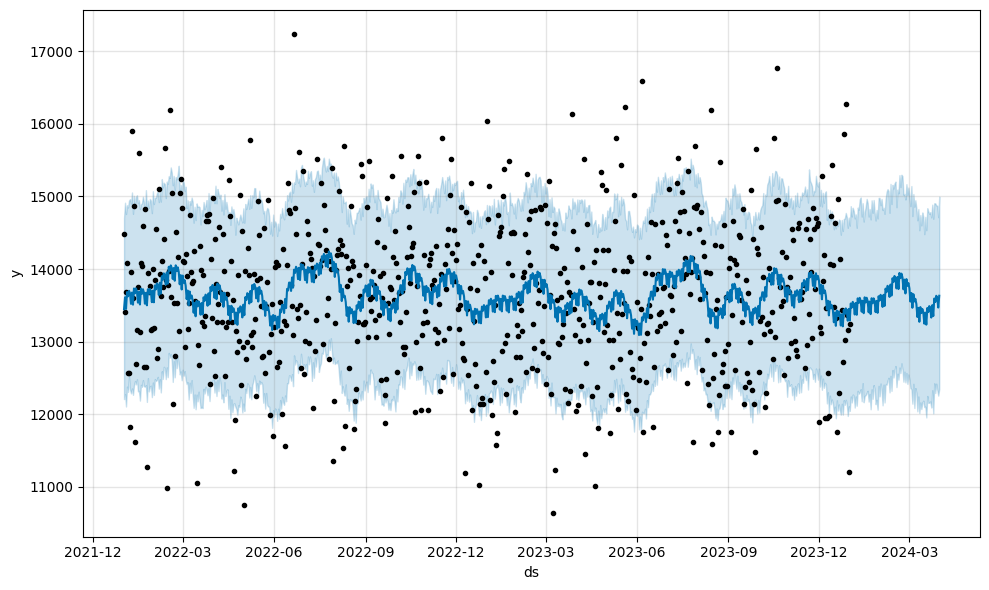

In [17]:
figl= model.plot(forecast)
plt.show()

In [19]:
actual = sales_df['y']

predicted = forecast['yhat'][:len(actual)]

mape = mean_absolute_percentage_error(actual, predicted)

rmse = np.sqrt(mean_squared_error(actual, predicted))

print("MAPE:", mape)
print("RMSE:", rmse)

accuracy = (1 - mape) * 100

print("Forecast Accuracy:", round(accuracy, 2), "%")

MAPE: 0.058997536051775906
RMSE: 1004.9473137596642
Forecast Accuracy: 94.1 %


In [22]:
forecast.to_csv("forecast_results.csv", index=False)